<a href="https://colab.research.google.com/github/optofficial2026/2026-OPT-1st-Homework/blob/seongwon/Week2/%EC%86%90%EC%84%B1%EC%9B%90%EC%9D%98_2%EC%A3%BC%EC%B0%A8_cnn%EA%B3%BC%EC%A0%9C_%EC%88%98%ED%96%89_CIFAR10_NN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Neural Network on CIFAR-10 with Regularization

In this assignment, you will:
1. Build a baseline CNN for CIFAR-10 classification
2. Implement and compare regularization techniques (Dropout, BatchNorm)
3. Combine all techniques to build your best model
4. Visualize how CNNs learn (filters, feature maps, Grad-CAM)
5. Analyze and compare results

**Rules:**
- You may use PyTorch (or TensorFlow if you prefer)
- Do NOT use pretrained models
- Fill in all `# TODO` sections
- Report final test accuracy for each experiment

---

## Grading Rubric

Your grade is determined by your **Best Model** (Task 4) **final test accuracy**, evaluated in Task 6:

| Grade | Test Accuracy | Description |
|-------|--------------|-------------|
| **A+** | >= 85% | Excellent — strong architecture with well-tuned regularization |
| **A** | >= 82% | Great — good combination of techniques |
| **B+** | >= 79% | Good effort — room for optimization |
| **B** | >= 76% | Decent — used some techniques effectively |
| **C** | >= 70% | Minimal effort — near baseline performance |
| **F** | < 70% | Needs more work |

**Per-task minimum thresholds** (must pass all to receive full credit):
- Task 1 (Baseline): >= 65% — confirms a working CNN
- Task 2 (Dropout): >= 65%
- Task 3 (BatchNorm): >= 70%
- Task 4 (Best Model): >= 70%
- Task 5 (Visualization): Complete all visualizations and answer questions
- Task 6 (Analysis): Answer all questions thoughtfully

## 0. Setup

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. Data Loading

CIFAR-10: 60,000 32x32 color images in 10 classes (50k train, 10k test).

We split the training set into **train (45k)** and **validation (5k)** so that we tune hyperparameters on the validation set and only evaluate on the test set at the very end.

In [8]:
# Basic transform (no augmentation yet)
transform_basic = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Full training set (we will split into train + val)
full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_basic)

# Split: 45k train, 5k validation
trainset, valset = torch.utils.data.random_split(full_trainset, [45000, 5000],
                                                  generator=torch.Generator().manual_seed(42))

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(valset, batch_size=128, shuffle=False, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_basic)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

## 2. Training & Evaluation Helpers

> **Note:** Dropout and BatchNorm behave differently during training vs. evaluation. The `train()` function calls `model.train()` and `evaluate()` calls `model.eval()` — this is critical for correct results.

In [13]:
def train(model, loader, criterion, optimizer, epochs=20):
    """Train the model. Returns lists of (train_loss, train_acc) per epoch."""

    # 모델을 '학습 모드'로 전환
    # (나중에 추가될 Dropout이나 BatchNorm이 훈련용으로 정상 작동하게 만듦)
    model.train()

    # 각 epoch마다 계산된 오차(loss)와 정확도(acc)를 모아둘 빈 기록장 준비
    # (나중에 학습이 잘 됐는지 그래프 그릴 때 사용)
    history = {'loss': [], 'acc': []}

    # 이만큼 epoch를 수행하겠다 (전체 문제집을 20번 반복해서 풀기)
    for epoch in range(epochs):
        # 이번 epoch에서 쌓일 오차 합, 맞춘 개수, 전체 문제 수를 0으로 초기화
        running_loss, correct, total = 0.0, 0, 0

        # 문제집(loader)에서 문제(inputs: 이미지)와 정답(labels)을 한 묶음(배치)씩 꺼내옴
        for inputs, labels in loader:
            # 꺼내온 문제와 정답을 작업대(GPU, device)로 보냄 (빠른 계산을 위해 필수!)
            inputs, labels = inputs.to(device), labels.to(device)

            # 1. 초기화: 이전 문제 풀 때 썼던 오답 노트(기울기)를 깨끗하게 지움
            # (안 지우면 이전 계산값이 누적돼서 학습이 산으로 감)
            optimizer.zero_grad()

            # 2. 예측(Forward): 모델한테 이미지를 주고 "이거 뭐야?" 하고 풀어보게 함
            outputs = model(inputs)

            # 3. 채점: 크로스엔트로피 채점관(criterion)이 정답과 예측값을 비교해 벌점(loss) 부여
            loss = criterion(outputs, labels)

            # 4. 반성(Backward): "왜 틀렸지?" 하고 오차를 거슬러 올라가며 마스크/노드의 수정 방향(기울기)을 계산
            loss.backward()

            # 5. 수정(Step): 과외선생님(optimizer)이 4번의 계산을 바탕으로 실제 뇌세포(파라미터) 숫자를 수정함 (★진짜 학습★)
            optimizer.step()

            # 진행 상황 기록 파트 -----------------------------------------
            # 이번 배치에서 나온 벌점 평균(loss.item())에 배치 크기를 곱해서 총 벌점에 누적
            # 기본적으로 loss는 batch당 loss임 이를 epoch당 loss로 변환
            running_loss += loss.item() * inputs.size(0)

            # 모델이 뱉은 10개 확률 중 가장 큰 값(argmax(1))의 인덱스가 실제 정답(labels)과 같으면 정답 처리!
            #correct에는 맞춘 문제 수가 저장 됨
            correct += (outputs.argmax(1) == labels).sum().item()

            # 이번에 푼 문제 개수(배치 크기)를 전체 누적 문제 수에 더함
            total += labels.size(0)

        # 한 epoch(문제집 1회독)가 끝났으니 최종 평균 오차와 정확도를 계산
        epoch_loss = running_loss / total
        epoch_acc = correct / total

        # 아까 만든 기록장에 이번 epoch 성적을 추가
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)

        # 각 epoch마다 결과 print (예: Epoch 1/20 — Loss: 1.4761, Acc: 0.4743)
        print(f'Epoch {epoch+1:2d}/{epochs} \u2014 Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}')
        #LR schedular사용 시에만 활성화
        #scheduler.step()

    # 20번 다 돌았으면 최종 성적 기록장 반환
    return history


def evaluate(model, loader):
    """Evaluate the model on a dataset. Returns (loss, accuracy)."""

    # 모델을 '시험(평가) 모드'로 전환
    # (Dropout 같은 꼼수 기능을 끄고 100% 진지하게 풀게 함)
    model.eval()

    # 시험용 채점관 모셔오기
    criterion = nn.CrossEntropyLoss()

    # 평가 점수 누적용 변수 초기화
    running_loss, correct, total = 0.0, 0, 0

    # ★ 핵심 ★ "이제부터 기울기(Gradient) 계산하지 마!"
    # 학습할(수정할) 게 아니니까 오답 노트 작성 기능을 완전히 끄는 마법의 주문.
    # 이렇게 하면 메모리도 엄청 아끼고 연산 속도도 훅 빨라집니다.
    with torch.no_grad():

        # 시험지(loader)에서 문제와 정답을 꺼내옴
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # 예측하고 채점만 함 (backward()나 step()이 없음!)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # 맞춘 개수와 오차 누적 (train 때와 동일)
            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    # 전체 시험 평균 오차와, 전체 정확도를 반환
    return running_loss / total, correct / total

---
## Task 1: Baseline CNN (No Regularization)

Build a simple CNN. Suggested architecture:
- 2~3 Conv blocks (Conv2d -> ReLU -> MaxPool2d)
- 1~2 Fully connected layers
- No dropout, no batch norm, no weight decay

In [11]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # --- [첫 번째 합성곱 블록 (Conv Block 1)] ---
        # 역할: 이미지에서 아주 기본적인 특징(선, 색, 모서리 등)을 찾아냅니다.
        # in_channels=3: 입력 이미지가 컬러(RGB) 채널 3개라는 뜻입니다. (흑백 이미지면 1로 수정)
        # out_channels=16: 16개의 서로 다른 필터(돋보기)를 사용해 16가지 특징을 뽑아냅니다.
        # padding=1: 필터를 거치면서 이미지 크기가 작아지는 것을 막기 위해 테두리에 0을 둘러줍니다.
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)

        # 활성화 함수 (ReLU): 계산 결과에서 음수 값은 0으로 날리고, 양수 값만 그대로 통과시킵니다.
        self.relu1 = nn.ReLU()

        # 풀링 계층 (MaxPool): 중요한 특징만 남기고 이미지 크기를 가로세로 정확히 절반(1/2)으로 줄입니다.
        # 예: 32x32 크기 이미지가 여기서 16x16으로 작아집니다.
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- [두 번째 합성곱 블록 (Conv Block 2)] ---
        # 역할: 첫 번째 블록에서 찾은 단순한 특징들을 엮어서 더 복잡한 형태(눈, 코, 바퀴 모양 등)를 파악합니다.
        # in_channels=16: 앞선 conv1의 출력 채널(16)을 그대로 이어받아야 데이터가 연결됩니다.
        # out_channels=32: 이번에는 32개의 더 다양한 필터를 사용해 특징을 심화시킵니다.
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()

        # 여기서 이미지가 다시 절반으로 줄어듭니다. (16x16 -> 8x8)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- [완전 연결 계층 (Fully Connected Layers)] ---
        # 역할: 지금까지 추출된 특징들을 종합해서 "이 이미지가 10개 클래스 중 무엇인지" 최종 점수를 매깁니다.
        # 입력 노드 수 계산: 마지막 채널 수(32) * 최종 세로(8) * 최종 가로(8) = 2048
        # 128은 중간 노드임 2048에서 바로 10으로 가면 너무 압축되어버려서 문제 생길 수 있음
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.relu3 = nn.ReLU()

        # 최종 출력: 10개의 클래스(예: 비행기, 자동차, 새 등)에 대한 예측 점수를 냅니다.
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # forward 함수는 데이터(x)가 실제로 모델 안에서 흘러가는(순전파) 순서를 정해줍니다.
        # 위에 정의한 cnn및 fc의 진행을 담당
        # 1. 첫 번째 블록 통과
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        # 2. 두 번째 블록 통과
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        # 3. 평탄화 (Flatten) 작업
        # 현재 x는 3차원 입체 형태(채널32 x 세로8 x 가로8)로 뭉쳐있습니다.
        # 이를 Linear 계층에 넣으려면 1차원의 긴 줄(2048 크기)로 쫙 펴주어야 합니다.
        # x.size(0)는 '배치 사이즈(한 번에 처리하는 이미지 장수)'를 의미하며, 이 단위는 깨지 않도록 고정합니다.
        x = x.view(x.size(0), -1)

        # 4. 분류기 통과
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc2(x)
        # 참고: loss 함수로 CrossEntropyLoss를 쓴다면, 마지막엔 별도의 활성화 함수 없이
        # 이 날것의 점수(Logit)를 그대로 return 하는 것이 파이토치의 규칙입니다.

        return x


baseline = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

hist_baseline = train(baseline, trainloader, criterion, optimizer, epochs=20)
val_loss, val_acc = evaluate(baseline, valloader)
print(f'\n[Baseline] Val Accuracy: {val_acc:.4f}')

Epoch  1/20 — Loss: 1.4971, Acc: 0.4638
Epoch  2/20 — Loss: 1.1451, Acc: 0.5975
Epoch  3/20 — Loss: 0.9968, Acc: 0.6536
Epoch  4/20 — Loss: 0.8968, Acc: 0.6874
Epoch  5/20 — Loss: 0.8112, Acc: 0.7172
Epoch  6/20 — Loss: 0.7466, Acc: 0.7393
Epoch  7/20 — Loss: 0.6890, Acc: 0.7570
Epoch  8/20 — Loss: 0.6283, Acc: 0.7806
Epoch  9/20 — Loss: 0.5718, Acc: 0.7993
Epoch 10/20 — Loss: 0.5158, Acc: 0.8217
Epoch 11/20 — Loss: 0.4613, Acc: 0.8402
Epoch 12/20 — Loss: 0.4105, Acc: 0.8598
Epoch 13/20 — Loss: 0.3574, Acc: 0.8764
Epoch 14/20 — Loss: 0.3063, Acc: 0.8964
Epoch 15/20 — Loss: 0.2679, Acc: 0.9078
Epoch 16/20 — Loss: 0.2280, Acc: 0.9220
Epoch 17/20 — Loss: 0.1904, Acc: 0.9361
Epoch 18/20 — Loss: 0.1666, Acc: 0.9444
Epoch 19/20 — Loss: 0.1327, Acc: 0.9565
Epoch 20/20 — Loss: 0.1155, Acc: 0.9623

[Baseline] Val Accuracy: 0.6866


---
## Task 2: Dropout Regularization

Copy your baseline and add **Dropout** layers. Experiment with dropout rates (e.g., 0.25, 0.5).

> **Tip:** Start with a lower rate like 0.25. High dropout (0.5) on small networks with few epochs can hurt training convergence — this is itself a useful observation.

In [40]:
class DropoutCNN(nn.Module):
    def __init__(self, drop_rate=0.5):
        super().__init__()


        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)

        self.relu1 = nn.ReLU()

        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()

        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.relu3 = nn.ReLU()

        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        # 1. 첫 번째 블록 통과
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        # 2. 두 번째 블록 통과
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        # 3. 평탄화 (Flatten) 작업
        x = x.view(x.size(0), -1)

        # 4. 분류기 통과
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc2(x)

        return x


dropout_model = DropoutCNN(drop_rate=0.25).to(device)
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

hist_dropout = train(dropout_model, trainloader, criterion, optimizer, epochs=20)
val_loss, val_acc = evaluate(dropout_model, valloader)
print(f'\n[Dropout] Val Accuracy: {val_acc:.4f}')

Epoch  1/20 — Loss: 1.5007, Acc: 0.4632
Epoch  2/20 — Loss: 1.1479, Acc: 0.5956
Epoch  3/20 — Loss: 1.0151, Acc: 0.6467
Epoch  4/20 — Loss: 0.9199, Acc: 0.6781
Epoch  5/20 — Loss: 0.8438, Acc: 0.7065
Epoch  6/20 — Loss: 0.7744, Acc: 0.7296
Epoch  7/20 — Loss: 0.7182, Acc: 0.7495
Epoch  8/20 — Loss: 0.6625, Acc: 0.7696
Epoch  9/20 — Loss: 0.6072, Acc: 0.7888
Epoch 10/20 — Loss: 0.5604, Acc: 0.8066
Epoch 11/20 — Loss: 0.5101, Acc: 0.8225
Epoch 12/20 — Loss: 0.4636, Acc: 0.8407
Epoch 13/20 — Loss: 0.4193, Acc: 0.8549
Epoch 14/20 — Loss: 0.3810, Acc: 0.8660
Epoch 15/20 — Loss: 0.3382, Acc: 0.8832
Epoch 16/20 — Loss: 0.2981, Acc: 0.8980
Epoch 17/20 — Loss: 0.2711, Acc: 0.9068
Epoch 18/20 — Loss: 0.2382, Acc: 0.9186
Epoch 19/20 — Loss: 0.2108, Acc: 0.9286
Epoch 20/20 — Loss: 0.1822, Acc: 0.9386

[Dropout] Val Accuracy: 0.6798


---
## Task 3: Batch Normalization

Copy your baseline and add **BatchNorm2d** (after conv layers) and/or **BatchNorm1d** (after FC layers).

In [25]:
class BatchNormCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        # 💡 Conv2d 바로 뒤에 BatchNorm2d를 붙입니다. (입력 채널 수는 conv1의 출력인 16)
        self.bn1 = nn.BatchNorm2d(16)


        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        # 💡 여기도 Conv2d 뒤에 붙입니다. (입력 채널 수는 conv2의 출력인 32)
        self.bn2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)


        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        # 💡 1차원으로 펴진 노드 뒤에는 BatchNorm1d를 씁니다. (입력 노드 수는 fc1의 출력인 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.relu3 = nn.ReLU()

        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # 1. 첫 번째 블록 통과
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        # 2. 두 번째 블록 통과
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        # 3. 평탄화 (Flatten) 작업
        x = x.view(x.size(0), -1)

        # 4. 분류기 통과
        x = self.fc1(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.fc2(x)

        return x


bn_model = BatchNormCNN().to(device)
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

hist_bn = train(bn_model, trainloader, criterion, optimizer, epochs=20)
val_loss, val_acc = evaluate(bn_model, valloader)
print(f'\n[BatchNorm] Val Accuracy: {val_acc:.4f}')

Epoch  1/20 — Loss: 1.2143, Acc: 0.5736
Epoch  2/20 — Loss: 0.8800, Acc: 0.6894
Epoch  3/20 — Loss: 0.7365, Acc: 0.7411
Epoch  4/20 — Loss: 0.6262, Acc: 0.7820
Epoch  5/20 — Loss: 0.5332, Acc: 0.8176
Epoch  6/20 — Loss: 0.4477, Acc: 0.8482
Epoch  7/20 — Loss: 0.3663, Acc: 0.8801
Epoch  8/20 — Loss: 0.2943, Acc: 0.9061
Epoch  9/20 — Loss: 0.2416, Acc: 0.9258
Epoch 10/20 — Loss: 0.1906, Acc: 0.9439
Epoch 11/20 — Loss: 0.1526, Acc: 0.9578
Epoch 12/20 — Loss: 0.1246, Acc: 0.9669
Epoch 13/20 — Loss: 0.1040, Acc: 0.9729
Epoch 14/20 — Loss: 0.0923, Acc: 0.9753
Epoch 15/20 — Loss: 0.0775, Acc: 0.9810
Epoch 16/20 — Loss: 0.0664, Acc: 0.9840
Epoch 17/20 — Loss: 0.0544, Acc: 0.9874
Epoch 18/20 — Loss: 0.0666, Acc: 0.9810
Epoch 19/20 — Loss: 0.0701, Acc: 0.9799
Epoch 20/20 — Loss: 0.0545, Acc: 0.9852

[BatchNorm] Val Accuracy: 0.6934


---
## Task 4: Best Model — Combine Everything

Now combine the techniques that worked best. Try to **maximize validation accuracy**. (Final test accuracy is evaluated once in Task 6.)

You may use any combination of:
- BatchNorm, Dropout
- Weight decay (`weight_decay` parameter in optimizer)
- Data augmentation (e.g., `RandomHorizontalFlip`, `RandomCrop`, `ColorJitter`)
- Deeper/wider architectures
- Learning rate scheduling (`optim.lr_scheduler`)
- More epochs
- Different optimizers (SGD + momentum)

In [12]:
# (Optional) Define an augmented transform for better training
transform_aug = transforms.Compose([
    # TODO: Add augmentation transforms here (e.g., RandomHorizontalFlip, RandomCrop)
    # 1. 패딩을 4만큼 주고 32x32로 무작위로 잘라냅니다. (사진 위치 살짝 흔들기)
    transforms.RandomCrop(32, padding=4),
    # 2. 50% 확률로 사진을 좌우로 뒤집습니다. (강아지가 왼쪽/오른쪽을 번갈아 보게 함)
    transforms.RandomHorizontalFlip(),
    # 3. 텐서로 변환 (필수) pytorch가 사용하기 편한 형태로 변형
    transforms.ToTensor(),
    # 4. 정규화 (CIFAR-10의 픽셀 평균/표준편차 값을 적용해 데이터를 예쁘게 정돈)
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

full_trainset_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_aug)
trainset_aug, _ = torch.utils.data.random_split(full_trainset_aug, [45000, 5000],
                                                 generator=torch.Generator().manual_seed(42))
trainloader_aug = torch.utils.data.DataLoader(trainset_aug, batch_size=128, shuffle=True, num_workers=2)


class BestCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # --- [Block 1] ---
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)

        # --- [Block 2] ---
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 128, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)

        # --- [Block 3] ---
        self.conv5 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(2, 2)

        # --- [Classifier (FC Layers)] ---
        # 32x32 이미지가 풀링을 3번 거치면 4x4 크기가 됩니다.
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.bn6 = nn.BatchNorm1d(512)

        # 과적합을 막기 위해 마지막 판단 직전에 뉴런의 50%를 무작위로 끕니다.
        self.drop = nn.Dropout(0.5)

        self.fc2 = nn.Linear(512, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        # Block 1
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)

        # Block 2
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)

        # Block 3
        x = self.relu(self.bn5(self.conv5(x)))
        x = self.pool3(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # FC Layers
        x = self.relu(self.bn6(self.fc1(x)))
        x = self.drop(x) # 💡 Dropout은 분류기 쪽에 하나만 강력하게 거는 게 정석입니다.
        x = self.fc2(x)

        return x


best_model = BestCNN().to(device)
# TODO: Choose optimizer, weight decay, scheduler
# 1. 옵티마이저를 Adam에서 SGD + Momentum으로 변경
# SGD는 Adam보다 똑똑하진 않지만, 관성(momentum)을 이용해 더 깊은 최적점을 찾아냅니다.
# 그냥 adam사용
optimizer = optim.Adam(best_model.parameters(), lr=1e-3, weight_decay=1e-4)
# 2. LR 스케줄러 추가 (StepLR)
# 10 에포크마다 학습률을 0.1배(1/10)로 줄여줍니다.
# 초반엔 0.1로 팍팍 배우다가, 10에포크 후엔 0.05, 20에포크 후엔 0.025로 조심스럽게 배웁니다.
#scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# You may use trainloader (no augmentation) or trainloader_aug (with augmentation)
hist_best = train(best_model, trainloader_aug, criterion, optimizer, epochs=30)
val_loss, val_acc = evaluate(best_model, valloader)
print(f'\n[Best Model] Val Accuracy: {val_acc:.4f}')

Epoch  1/30 — Loss: 1.8276, Acc: 0.4045
Epoch  2/30 — Loss: 1.1289, Acc: 0.5946
Epoch  3/30 — Loss: 0.9029, Acc: 0.6822
Epoch  4/30 — Loss: 0.7893, Acc: 0.7252
Epoch  5/30 — Loss: 0.7226, Acc: 0.7517
Epoch  6/30 — Loss: 0.6771, Acc: 0.7656
Epoch  7/30 — Loss: 0.6293, Acc: 0.7835
Epoch  8/30 — Loss: 0.6095, Acc: 0.7905
Epoch  9/30 — Loss: 0.5832, Acc: 0.8015
Epoch 10/30 — Loss: 0.5624, Acc: 0.8074
Epoch 11/30 — Loss: 0.4508, Acc: 0.8489
Epoch 12/30 — Loss: 0.4235, Acc: 0.8543
Epoch 13/30 — Loss: 0.4101, Acc: 0.8598
Epoch 14/30 — Loss: 0.4067, Acc: 0.8619
Epoch 15/30 — Loss: 0.4049, Acc: 0.8619
Epoch 16/30 — Loss: 0.3936, Acc: 0.8654
Epoch 17/30 — Loss: 0.3892, Acc: 0.8660
Epoch 18/30 — Loss: 0.3919, Acc: 0.8658
Epoch 19/30 — Loss: 0.3788, Acc: 0.8722
Epoch 20/30 — Loss: 0.3697, Acc: 0.8738
Epoch 21/30 — Loss: 0.2870, Acc: 0.9029
Epoch 22/30 — Loss: 0.2675, Acc: 0.9080
Epoch 23/30 — Loss: 0.2621, Acc: 0.9106
Epoch 24/30 — Loss: 0.2586, Acc: 0.9110
Epoch 25/30 — Loss: 0.2568, Acc: 0.9121


---
## Task 5: Visualizing How CNNs Work

Understanding what happens inside a CNN is crucial for building intuition. In this section you will:

1. **Visualize first-layer convolutional filters** — what low-level patterns does the network learn?
2. **Visualize feature maps (activations)** — how does each layer transform the input image?
3. **Grad-CAM heatmaps** — where does the model "look" when making a prediction?
4. **Compare Baseline vs BatchNorm** — how does BatchNorm affect what the CNN learns?

The helper functions are provided below. Your job is to **call them on your trained models**, observe the outputs, and **answer the questions**.

In [15]:
# ===== Visualization Helpers (provided — do not modify) =====

def show_original_image(image, label=None):
    """Display a single CIFAR-10 image (un-normalized)."""
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    img = image.cpu() * std + mean
    img = img.clamp(0, 1)
    plt.figure(figsize=(2, 2))
    plt.imshow(img.permute(1, 2, 0).numpy())
    if label is not None:
        plt.title(f"Label: {classes[label]}")
    plt.axis('off')
    plt.show()


def _get_conv_layers(model):
    """Return an ordered list of (name, Conv2d module) from the model."""
    convs = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            convs.append((name, module))
    return convs


def visualize_filters(model, title="First Conv Layer Filters"):
    """Visualize the filters of the first Conv2d layer."""
    conv_layers = _get_conv_layers(model)
    if not conv_layers:
        print("No Conv2d layers found in model.")
        return
    first_conv = conv_layers[0][1]
    filters = first_conv.weight.data.cpu().clone()
    n = min(filters.shape[0], 16)
    fig, axes = plt.subplots(2, 8, figsize=(14, 3.5))
    for i, ax in enumerate(axes.flat):
        if i < n:
            f = filters[i]
            f = (f - f.min()) / (f.max() - f.min())
            ax.imshow(f.permute(1, 2, 0).numpy())
        ax.axis('off')
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def visualize_feature_maps(model, image, title="Feature Maps"):
    """Visualize feature maps at each Conv2d layer for a single image."""
    model.eval()
    conv_layers = _get_conv_layers(model)
    if not conv_layers:
        print("No Conv2d layers found in model.")
        return

    # Register forward hooks on all conv layers
    activations = {}
    hooks = []
    for name, layer in conv_layers:
        def hook_fn(module, input, output, name=name):
            activations[name] = output.detach().cpu().squeeze(0)
        hooks.append(layer.register_forward_hook(hook_fn))

    # Forward pass
    with torch.no_grad():
        x = image.unsqueeze(0).to(device)
        model(x)

    # Remove hooks
    for h in hooks:
        h.remove()

    # Plot
    for i, (name, _) in enumerate(conv_layers):
        act = activations[name]
        n_ch = min(act.shape[0], 8)
        fig, axes = plt.subplots(1, n_ch, figsize=(n_ch * 2, 2))
        if n_ch == 1:
            axes = [axes]
        for j in range(n_ch):
            axes[j].imshow(act[j], cmap='viridis')
            axes[j].axis('off')
        label = f"Conv {i+1} (ch={act.shape[0]}, {act.shape[1]}x{act.shape[2]})"
        plt.suptitle(f"{title} \u2014 {label}", fontsize=12)
        plt.tight_layout()
        plt.show()


def grad_cam(model, image, target_class=None):
    """Compute Grad-CAM heatmap for the last Conv2d layer."""
    import torch.nn.functional as F
    model.eval()

    conv_layers = _get_conv_layers(model)
    if not conv_layers:
        raise ValueError("No Conv2d layers found in model.")
    last_conv = conv_layers[-1][1]

    gradients, activations_list = [], []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    def forward_hook(module, input, output):
        activations_list.append(output)

    handle_f = last_conv.register_forward_hook(forward_hook)
    handle_b = last_conv.register_full_backward_hook(backward_hook)

    input_tensor = image.unsqueeze(0).to(device).requires_grad_(True)
    output = model(input_tensor)
    if target_class is None:
        target_class = output.argmax(1).item()
    model.zero_grad()
    output[0, target_class].backward()

    grads = gradients[0].cpu().data.numpy()[0]
    acts = activations_list[0].cpu().data.numpy()[0]
    weights = np.mean(grads, axis=(1, 2))
    cam = np.sum(weights[:, None, None] * acts, axis=0)
    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)

    cam_tensor = torch.from_numpy(cam).unsqueeze(0).unsqueeze(0).float()
    cam_resized = F.interpolate(cam_tensor, size=(32, 32), mode='bilinear', align_corners=False)
    cam_resized = cam_resized.squeeze().numpy()

    handle_f.remove()
    handle_b.remove()
    return cam_resized, target_class


def show_grad_cam(model, image, label=None, title="Grad-CAM"):
    """Display Grad-CAM heatmap overlaid on the original image."""
    cam, pred_class = grad_cam(model, image)
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    img = (image.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis('off')
    axes[1].imshow(cam, cmap='jet')
    axes[1].set_title("Grad-CAM")
    axes[1].axis('off')
    axes[2].imshow(img)
    axes[2].imshow(cam, cmap='jet', alpha=0.5)
    axes[2].set_title(f"Overlay (pred: {classes[pred_class]})")
    axes[2].axis('off')
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

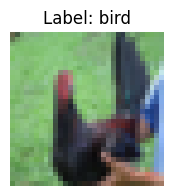

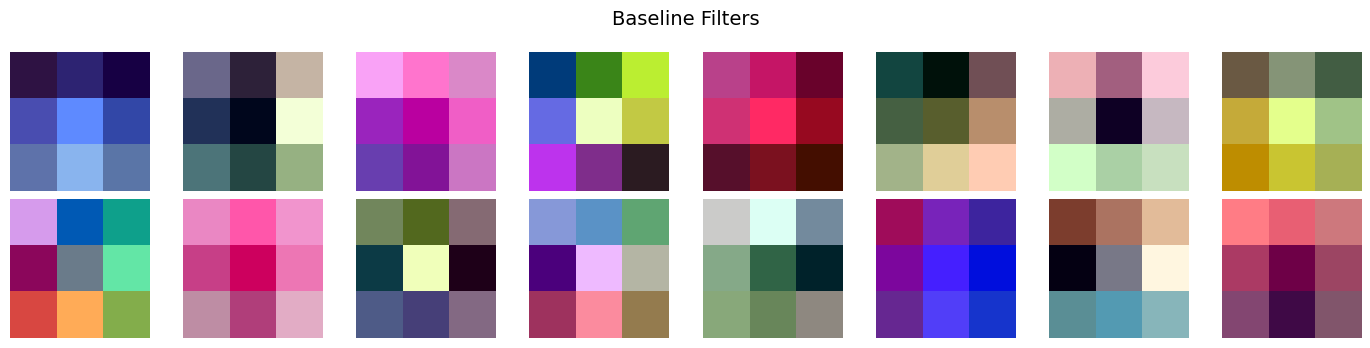

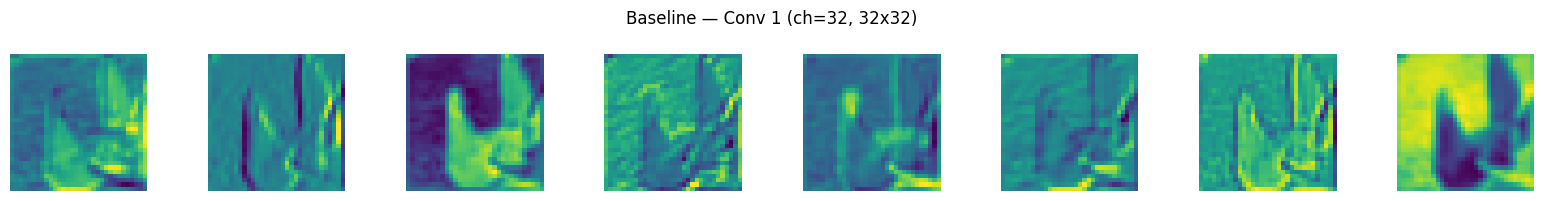

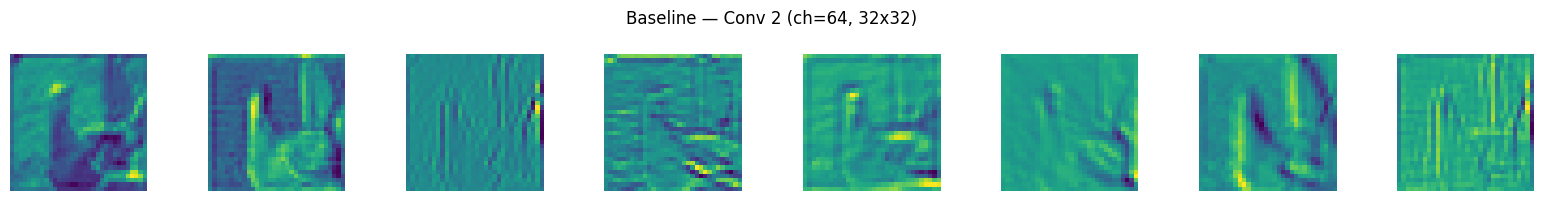

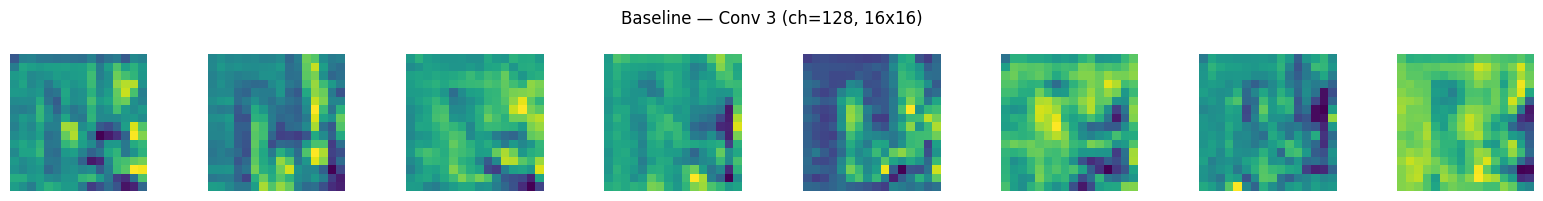

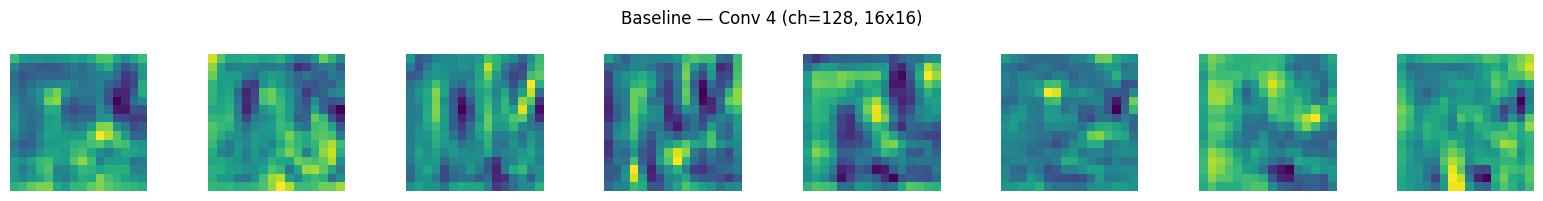

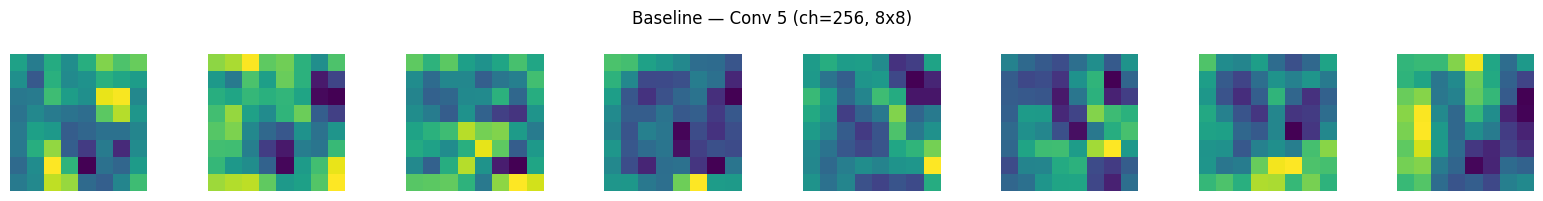

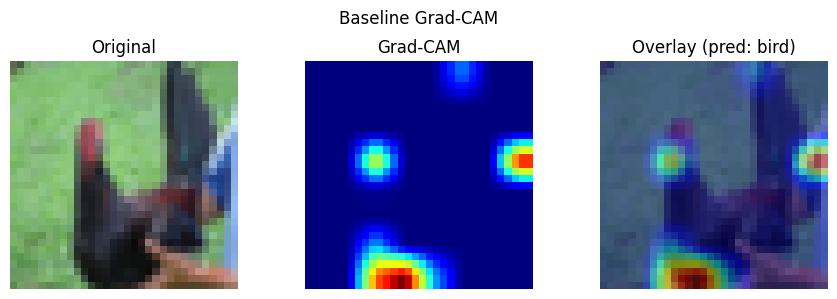

In [43]:
# --- Pick a sample image for visualization ---
sample_image, sample_label = testset[25]
show_original_image(sample_image, sample_label)

# TODO: Visualize first-layer filters for Baseline and BatchNorm models
#visualize_filters(baseline, title="Baseline Filters")
#visualize_filters(bn_model, title="BatchNorm Filters")
visualize_filters(best_model, title="Baseline Filters")


# TODO: Visualize feature maps for both models on the sample image
#visualize_feature_maps(baseline, sample_image, title="Baseline")
#visualize_feature_maps(bn_model, sample_image, title="BatchNorm")
visualize_feature_maps(best_model, sample_image, title="Baseline")

# TODO: Show Grad-CAM heatmaps for both models
#show_grad_cam(baseline, sample_image, title="Baseline Grad-CAM")
#show_grad_cam(bn_model, sample_image, title="BatchNorm Grad-CAM")
show_grad_cam(best_model, sample_image, title="Baseline Grad-CAM")

# TODO: Try at least 3 different images from different classes and compare.
#       Do the models focus on different regions?

### 5-1. Observation Questions

1. Describe the patterns you see in the first-layer filters. Do they resemble edge detectors, color detectors, or something else?
2. How do feature maps change from the first conv layer to the last? What does this suggest about hierarchical feature learning?
3. Compare the Grad-CAM heatmaps of the Baseline and BatchNorm models. Does one focus on more relevant image regions?
4. Did you find any images where one model's attention (Grad-CAM) was clearly better than the other's? Describe what you found.

*Your observations here*
* 1번 -> 필터에서 엣지를 기준으로 나눠지며 색에 대해서도 다르게 반영되는게 보임
* 2번 -> 층을 거듭할 수록 알아보기 힘들어짐 즉, 다시 말해서 모델은 기초적인 요소에서 점점 고차원의 개념을 기준으로 판단하게 됨
* 3번 -> baseline은 아무데나 점을 찍음 bn모델은 고양이가 빨갛게 되어있음
* 4번 -> 25번 사진을 테스트할 때 base는 주변이 빨게졌는데 bn은 대상인 닭이 빨게짐 이는 base의 과적합의 결과로 생각됨!

---
## Task 6: Analysis

### 6-1. Compare Results

Final Test Set Evaluation:
  Baseline       : 0.6826
  Dropout        : 0.6813
  BatchNorm      : 0.6890
  Best Model     : 0.8558


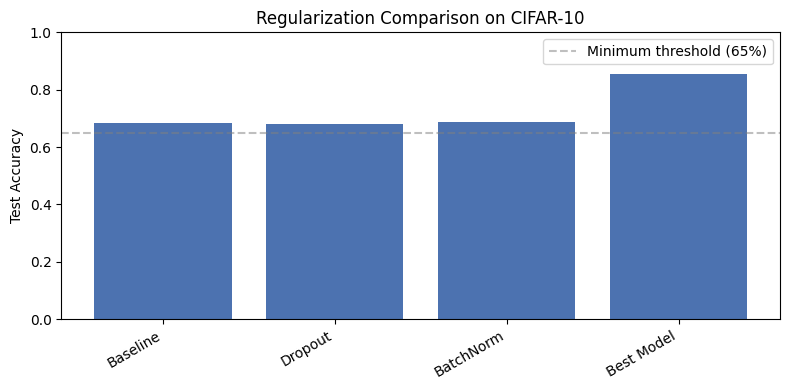

           AUTO-GRADE REPORT
  Baseline            : 68.3%  (>= 65%)  [PASS]
  Dropout             : 68.1%  (>= 65%)  [PASS]
  BatchNorm           : 68.9%  (>= 70%)  [FAIL]
  Best Model          : 85.6%  (>= 70%)  [PASS]
---------------------------------------------
  Best Model Accuracy : 85.6%
  Grade               : A+


In [41]:
# Final evaluation on the TEST set (only done here, after all tuning is complete)
print('Final Test Set Evaluation:')
print('=' * 40)
results = {}
for name, model in [('Baseline', baseline), ('Dropout', dropout_model),
                     ('BatchNorm', bn_model), ('Best Model', best_model)]:
    _, acc = evaluate(model, testloader)
    results[name] = acc
    print(f'  {name:15s}: {acc:.4f}')
print('=' * 40)

# --- Bar Chart ---
plt.figure(figsize=(8, 4))
colors = ['#4C72B0' if v >= 0.65 else '#C44E52' for v in results.values()]
plt.bar(results.keys(), results.values(), color=colors)
plt.ylabel('Test Accuracy')
plt.title('Regularization Comparison on CIFAR-10')
plt.ylim(0, 1)
plt.axhline(y=0.65, color='gray', linestyle='--', alpha=0.5, label='Minimum threshold (65%)')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# --- Auto-Grading ---
def compute_grade(best_acc):
    if best_acc >= 0.85: return 'A+'
    elif best_acc >= 0.82: return 'A'
    elif best_acc >= 0.79: return 'B+'
    elif best_acc >= 0.76: return 'B'
    elif best_acc >= 0.70: return 'C'
    else: return 'F'

thresholds = {
    'Baseline': 0.65,
    'Dropout': 0.65,
    'BatchNorm': 0.70,
    'Best Model': 0.70,
}

print('=' * 45)
print('           AUTO-GRADE REPORT')
print('=' * 45)
all_pass = True
for task, threshold in thresholds.items():
    acc = results[task]
    passed = acc >= threshold
    status = 'PASS' if passed else 'FAIL'
    if not passed:
        all_pass = False
    print(f'  {task:20s}: {acc:.1%}  (>= {threshold:.0%})  [{status}]')

best = results['Best Model']
grade = compute_grade(best)
print('-' * 45)
print(f'  Best Model Accuracy : {best:.1%}')
print(f'  Grade               : {grade}')
if not all_pass:
    print('  WARNING: Some tasks below minimum threshold!')
print('=' * 45)

### 6-2. Training Curves

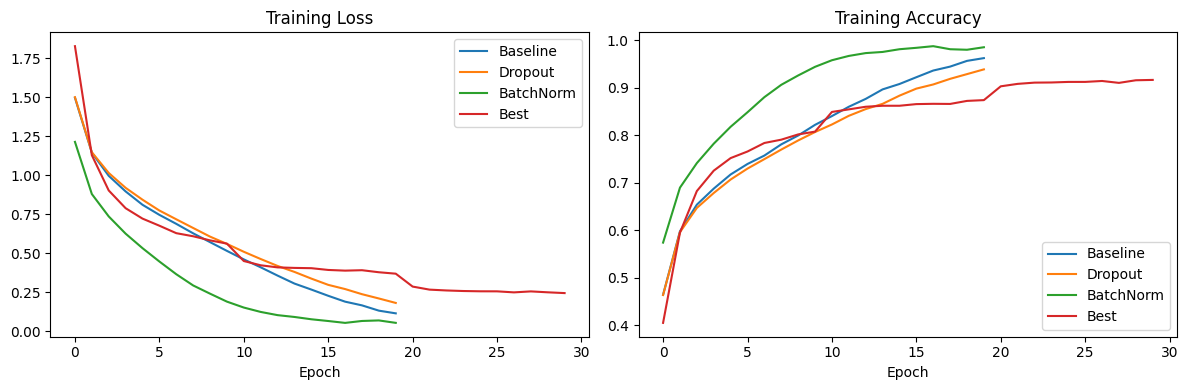

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for name, hist in [('Baseline', hist_baseline), ('Dropout', hist_dropout),
                    ('BatchNorm', hist_bn), ('Best', hist_best)]:
    ax1.plot(hist['loss'], label=name)
    ax2.plot(hist['acc'], label=name)

ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.set_title('Training Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.show()

### 6-3. Questions (Answer in text cells below)

1. Which regularization technique (Dropout vs BatchNorm) gave the bigger improvement over the baseline? Why do you think so?
2. Compare the training curves (loss & accuracy) of the baseline vs. your best model. What differences do you observe regarding overfitting?
3. Based on your Grad-CAM visualizations from Task 5, which model (Baseline vs BatchNorm) focuses on more task-relevant image regions? How might this relate to their accuracy difference?

*Your answers here*
* Dropout이 더 regularization에 도움을 많이 줬다 그 이유는 훈련 성능은 비슷한데 훈련 정확도가 bn이 더 높기 때문이다.
* best모델이 오히려 훈련시 정확도가 떨어짐 대신 성능은 더 좋았다 그 이유는 베스트 모델은 각종 기법에 의해 과적합상태에 빠지지 않아서 새로운데이터에 대해서도 민감하게 반응할 수 있었다.
* bn모데링 더욱 대상에 가까운 부분에 빨간 점을 찍었습니다. 그리고 이러한 차이는 bn에서는 정규화를 통해서 배경에 현혹되지않고 사물의 본질을 학습할 수 있게 되기 때문입니다